# 🧹 CSV Cleaner - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/csv-cleaner/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/csv-cleaner/demo.ipynb)

> *"Our data exports are always messy."*

Smart-quoted headers, trailing spaces, `N/A` strings, blank rows, duplicate records,
collided column names. This notebook runs a deterministic, **auditable** cleanup and
reports exactly what changed - no silent magic.

**What we cover**
1. Look at a realistically messy CSV
2. Normalize headers
3. Trim, nullify, drop empties + dupes
4. Coerce numeric columns
5. Visualize the before/after shrink
6. Try your own file


## Step 1 - A realistically messy export

Note the offenders: spaces in `Order ID `, a duplicated `Amount` header, `N/A`
strings, a fully-blank row, an exact duplicate row, mixed-case `Status`.


In [1]:
from __future__ import annotations

import io
import re
from typing import Dict, List, Tuple

import pandas as pd

MESSY = """Order ID , Customer Name ,Amount,Amount,Status,Notes
1001, Alice  ,12.50,12.50,Paid,
1002,Bob,N/A,N/A,paid ,
1002,Bob,N/A,N/A,paid ,
,,,,,
1003, Carol ,99.00,99.00, Refunded ,-
1004,Dan ,  7.25 ,7.25,PENDING,#N/A
"""

raw = pd.read_csv(io.StringIO(MESSY), dtype=str, keep_default_na=False, skip_blank_lines=False)
print("Raw shape:", raw.shape)
raw

Raw shape: (6, 6)


,Order ID,Customer Name,Amount,Amount.1,Status,Notes
0,1001,Alice,12.50,12.50,Paid,
1,1002,Bob,N/A,N/A,paid,
2,1002,Bob,N/A,N/A,paid,
3,,,,,,
4,1003,Carol,99.00,99.00,Refunded,-
5,1004,Dan,7.25,7.25,PENDING,#N/A


## Step 2 - Normalize headers

Trim, lowercase, snake_case, and de-collide duplicates (`amount`, `amount_1`).


In [2]:
NULL_TOKENS = {"", "na", "n/a", "null", "none", "-", "--", "nan", "?", "#n/a"}

def normalize_header(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[^\w]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name or "unnamed"

def _dedupe_headers(headers: List[str]) -> List[str]:
    seen: Dict[str, int] = {}
    out: List[str] = []
    for h in headers:
        if h in seen:
            seen[h] += 1
            out.append(f"{h}_{seen[h]}")
        else:
            seen[h] = 1
            out.append(h)
    return out

print([normalize_header(c) for c in raw.columns])
print(_dedupe_headers([normalize_header(c) for c in raw.columns]))

['order_id', 'customer_name', 'amount', 'amount_1', 'status', 'notes']
['order_id', 'customer_name', 'amount', 'amount_1', 'status', 'notes']


## Step 3-4 - Full clean with a change report

One function: trim cells, convert null-tokens to real NaN, drop empty rows/cols,
drop duplicate rows, and coerce columns that are ≥90% numeric.


In [3]:
def clean_dataframe(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, int]]:
    report: Dict[str, int] = {}
    start_rows = len(df)
    df = df.copy()
    df.columns = _dedupe_headers([normalize_header(c) for c in df.columns])

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].map(lambda v: v.strip() if isinstance(v, str) else v)

    def _nullify(v):
        if isinstance(v, str) and v.strip().lower() in NULL_TOKENS:
            return pd.NA
        return v
    df = df.map(_nullify)

    before = len(df); df = df.dropna(how="all")
    report["empty_rows_dropped"] = before - len(df)
    before_cols = df.shape[1]; df = df.dropna(axis=1, how="all")
    report["empty_cols_dropped"] = before_cols - df.shape[1]
    before = len(df); df = df.drop_duplicates()
    report["duplicate_rows_dropped"] = before - len(df)

    coerced = 0
    for col in df.select_dtypes(include="object").columns:
        converted = pd.to_numeric(df[col], errors="coerce")
        non_null = df[col].notna().sum()
        if non_null > 0 and converted.notna().sum() >= 0.9 * non_null:
            df[col] = converted; coerced += 1
    report["columns_coerced_numeric"] = coerced

    df = df.reset_index(drop=True)
    report["rows_in"] = start_rows; report["rows_out"] = len(df)
    return df, report

clean, report = clean_dataframe(raw)
print(report)
clean

{'empty_rows_dropped': 1, 'empty_cols_dropped': 1, 'duplicate_rows_dropped': 1, 'columns_coerced_numeric': 3, 'rows_in': 6, 'rows_out': 4}


,order_id,customer_name,amount,amount_1,status
0,1001,Alice,12.50,12.50,Paid
1,1002,Bob,NaN,NaN,paid
2,1003,Carol,99.00,99.00,Refunded
3,1004,Dan,7.25,7.25,PENDING


## Step 5 - Before / after, visualized

The cleanup removed a blank row, an exact duplicate, and an all-empty `notes`
column - and turned `amount` into real numbers.


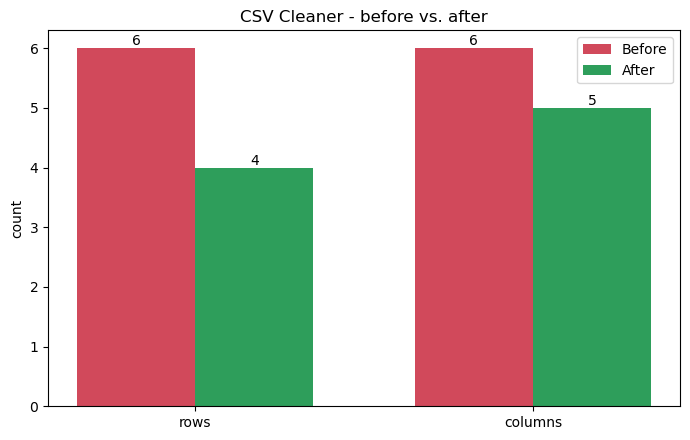

In [4]:
import matplotlib.pyplot as plt

labels = ["rows", "columns"]
before = [raw.shape[0], raw.shape[1]]
after = [clean.shape[0], clean.shape[1]]

import numpy as np
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, before, w, label="Before", color="#d1495b")
ax.bar(x + w/2, after, w, label="After", color="#2e9e5b")
for i, (b, a) in enumerate(zip(before, after)):
    ax.text(i - w/2, b + 0.05, str(b), ha="center", fontsize=10)
    ax.text(i + w/2, a + 0.05, str(a), ha="center", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("count"); ax.set_title("CSV Cleaner - before vs. after")
ax.legend(); plt.tight_layout()
plt.savefig("cleanup.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Change | Count |
|--------|-------|
| Empty rows dropped | 1 |
| Empty columns dropped | 1 |
| Duplicate rows dropped | 1 |
| Columns coerced to numeric | 3 |

Headers are now snake_case and de-collided; `N/A`/`-`/`#N/A` became real nulls.


## 🔧 Try your own file

```python
# my = pd.read_csv("your_messy_export.csv", dtype=str, keep_default_na=False)
# cleaned, report = clean_dataframe(my)
# print(report)
# cleaned.to_csv("your_clean_export.csv", index=False)
# cleaned.head()
```


In [5]:
# Paste a path above and uncomment to clean your own export.
print("Ready - drop in your own CSV path.")

Ready - drop in your own CSV path.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run it as a CLI:**
```bash
pip install -r requirements.txt
python main.py --demo            # clean a bundled messy sample
python main.py messy.csv -o tidy.csv
```
